In [60]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import calendar
import numpy as np

In [61]:
#  data loading
train: pd.DataFrame = pd.read_csv('train.csv')
test: pd.DataFrame = pd.read_csv('test.csv')

date_col = 'id'
target_col = 'value'

original_test_date = test[date_col]

In [62]:
#  data preprocessing
train[date_col] = pd.to_datetime(train[date_col], format="%m/%d/%y")
test[date_col] = pd.to_datetime(test[date_col], format="%m/%d/%y")

# create new month index column
train["month"] = train[date_col].dt.month
test["month"] = test[date_col].dt.month

In [63]:
#  form training and test samples
X_train = train[["month"]]
y_train = train[target_col]
X_test = test[["month"]]

In [64]:
#  model training
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

spline_model = make_pipeline(
    SplineTransformer(
        n_knots=5,
        degree=3,
    ),
    LinearRegression()
)
spline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('splinetransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_knots n_knots: int, default=5Number of knots of the splines if `knots` equals one of{'uniform', 'quantile'}. Must be larger or equal 2. Ignored if `knots`is array-like.",5
,"degree degree: int, default=3The polynomial degree of the spline basis. Must be a non-negativeinteger.",3
,"knots knots: {'uniform', 'quantile'} or array-like of shape (n_knots, n_features), default='uniform'Set knot positions such that first knot <= features <= last knot.- If 'uniform', `n_knots` number of knots are distributed uniformly from min to max values of the features.- If 'quantile', they are distributed uniformly along the quantiles of the features.- If an array-like is given, it directly specifies the sorted knot positions including the boundary knots. Note that, internally, `degree` number of knots are added before the first knot, the same after the last knot.",'uniform'
,"extrapolation extrapolation: {'error', 'constant', 'linear', 'continue', 'periodic'}, default='constant'If 'error', values outside the min and max values of the trainingfeatures raises a `ValueError`. If 'constant', the value of thesplines at minimum and maximum value of the features is used asconstant extrapolation. If 'linear', a linear extrapolation is used.If 'continue', the splines are extrapolated as is, i.e. option`extrapolate=True` in :class:`scipy.interpolate.BSpline`. If'periodic', periodic splines with a periodicity equal to the distancebetween the first and last knot are used. Periodic splines enforceequal function values and derivatives at the first and last knot.For example, this makes it possible to avoid introducing an arbitraryjump between Dec 31st and Jan 1st in spline features derived from anaturally periodic ""day-of-year"" input feature. In this case it isrecommended to manually set the knot values to control the period.",'constant'
,"include_bias include_bias: bool, default=TrueIf False, then the last spline element inside the data rangeof a feature is dropped. As B-splines sum to one over the spline basisfunctions for each data point, they implicitly include a bias term,i.e. a column of ones. It acts as an intercept term in a linear models

In [65]:
#  MSE on training set for spline regression
train_preds_spline = spline_model.predict(X_train)
mse_train_spline: float = mean_squared_error(y_train, train_preds_spline)
print(f"MSE on training set for spline regression: {mse_train_spline:.4f}")

predictions = spline_model.predict(X_test).round(4)

# fulfill the file for uploading
test[date_col] = original_test_date
test[target_col] = predictions
test = test.drop(columns=["month"])
test.to_csv('submission.csv', index=False)

MSE on training set for spline regression: 6.1285


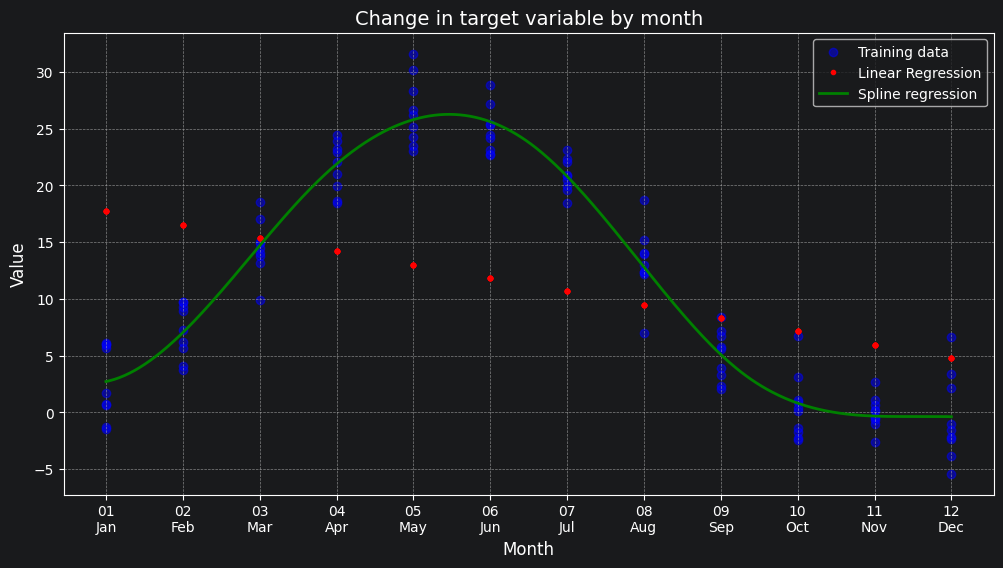

In [66]:
# data visualization
linear_preds = linear_model.predict(X_train).round(4)
spline_preds = spline_model.predict(X_train).round(4)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(X_train['month'], y_train, color='blue', alpha=0.5, label='Training data')

ax.plot(X_train["month"], linear_preds, '.', color='red', label='Linear Regression', linewidth=2)
X_plot = np.linspace(X_train.min(), X_train.max(), 500)
X_plot = pd.DataFrame(X_plot, columns=["month"])
y_plot = spline_model.predict(X_plot)
ax.plot(X_plot['month'], y_plot, color='green', linewidth=2, label='Spline regression')
months = np.arange(1, 13)
labels = [f"{m:02d}\n{calendar.month_abbr[m]}" for m in months]
ax.set_xticks(months)
ax.set_xticklabels(labels, fontsize=10)

ax.set_title('Change in target variable by month', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Value', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()